Claude Code wrote this notebook and the training scripts for the below 48 checkpoints.

# M3 / M4 — True vs. Learned Distributions of y

We compare the **true** distribution of the 2-D response `y` against the distributions learned by the conditional **diffusion** model and the conditional **WGAN**, for both data models `M3` and `M4`.

For every method and data model we plot:

- the **unconditional** distribution `p(y)` (drawing `x ~ N(0, 1)`), and
- the **conditional** distribution `p(y | x)` for a fixed, user-defined value of `x`.

### Checkpoints wired in (seed 1 only)

**Diffusion** — architectures `mlp` (baseline), `film`, `deep`, each trained with `adamw` and `muon`: 6 per data model, 12 total. Diffusion has no recon-weight term.

**WGAN** — architectures `mlp` (baseline), `film`, `deep`, each trained with three optimizer variants — `adamw`, `muon` (Muon's default momentum 0.95), and `muon m=0` (Muon with momentum 0) — and with recon-weight 0 and 0.1: 18 per data model, 36 total. Every WGAN run uses leaky-slope 0.01 and `n_critic = 1`. The `film` and `deep` architectures are applied to both the generator and the critic.

### Producing the checkpoints

Run the training script **from the repository root** before running this notebook:

```
bash scripts/train_checkpoints.sh
```

It trains all 48 checkpoints (seed 1), one at a time, into `m3m4/diffusion/notebook_ckpts/` and `m3m4/wgan/notebook_ckpts/`. It is **resumable** — any checkpoint already on disk is skipped, so if the run is interrupted just run it again and it picks up where it left off. Override the device (default `mps`) with:

```
DEVICE=cuda bash scripts/train_checkpoints.sh
```

Missing checkpoints are skipped here and shown as blank panels, so the notebook still runs end-to-end without them.

In [1]:
# Run this notebook from the m3m4/ directory so that `diffusion` and `wgan`
# import as packages.
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.model import make_denoiser, make_scheduler, sample_y
from wgan.model import make_generator, make_critic, mc_generate

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## Checkpoint registry

File-path conventions matching `scripts/train_notebook_checkpoints.sh`. Diffusion varies over architecture and optimizer (6 per data model); WGAN additionally varies over recon-weight (12 per data model).

In [2]:
# Paths are relative to this notebook (the m3m4/ directory) and match the
# layout written by scripts/train_checkpoints.sh.
DIFF_DIR = "diffusion/notebook_ckpts"
WGAN_DIR = "wgan/notebook_ckpts"

ARCHS = ["mlp", "film", "deep"]
RECON_WEIGHTS = [("0", "0"), ("0.1", "01")]  # (display label, filename tag)

# Optimizer variants: (display label, filename tag, color).
DIFF_OPTS = [
    ("adamw", "adamw", "tab:blue"),
    ("muon", "muon", "tab:orange"),
]
WGAN_OPTS = [
    ("adamw", "adamw", "tab:blue"),
    ("muon", "muon", "tab:orange"),
    ("muon m=0", "muonm0", "tab:green"),  # Muon with momentum 0
]


def diffusion_panels(data_model):
    """6 checkpoints per data model: arch x optimizer."""
    m = data_model.lower()
    panels = []
    for arch in ARCHS:
        for label, tag, color in DIFF_OPTS:
            panels.append((
                arch + " / " + label,
                DIFF_DIR + "/" + m + "_" + arch + "_" + tag + ".pt",
                color,
            ))
    return panels


def wgan_panels(data_model):
    """18 checkpoints per data model: arch x optimizer x recon-weight."""
    m = data_model.lower()
    panels = []
    for arch in ARCHS:
        for label, tag, color in WGAN_OPTS:
            for rlabel, rtag in RECON_WEIGHTS:
                panels.append((
                    arch + " / " + label + " / recon " + rlabel,
                    WGAN_DIR + "/" + m + "_" + arch + "_" + tag + "_recon" + rtag + ".pt",
                    color,
                ))
    return panels


print("diffusion checkpoints per data model:", len(diffusion_panels("M3")))
print("wgan checkpoints per data model:     ", len(wgan_panels("M3")))

diffusion checkpoints per data model: 6
wgan checkpoints per data model:      18


## Loading checkpoints and sampling

Diffusion checkpoints store the EMA denoiser; we rebuild the scheduler and run `sample_y`. WGAN checkpoints store the EMA generator; we run it through `mc_generate` and un-standardize with the stored `y_mean` / `y_std`.

In [3]:
def load_denoiser(path):
    ckpt = torch.load(path, map_location="cpu")
    model = make_denoiser(ckpt["arch"], t_dim=ckpt["t_dim"]).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    scheduler = make_scheduler(ckpt["num_train_timesteps"])
    scheduler.config.clip_sample = False
    return model, scheduler, ckpt


def load_generator(path):
    ckpt = torch.load(path, map_location="cpu")
    g = make_generator(ckpt["arch"], z_dim=ckpt["z_dim"], leaky_slope=ckpt["leaky_slope"])
    g = g.to(device)
    g.load_state_dict(ckpt["g_ema_state"])
    g.eval()
    return g, ckpt


@torch.no_grad()
def diffusion_samples(path, x):
    model, scheduler, ckpt = load_denoiser(path)
    y = sample_y(
        model,
        x.to(device),
        scheduler,
        ckpt["y_mean"].to(device),
        ckpt["y_std"].to(device),
        num_inference_steps=ckpt["num_inference_steps"],
    )
    return y.cpu().numpy()


@torch.no_grad()
def wgan_samples(path, x):
    g, ckpt = load_generator(path)
    fake = mc_generate(g, x.to(device), z_dim=ckpt["z_dim"], J=1)[0]
    y = fake * ckpt["y_std"].to(device) + ckpt["y_mean"].to(device)
    return y.cpu().numpy()


def gather(method, data_model, x):
    """Sample every checkpoint for (method, data_model); skip missing ones.

    Returns a list of (label, samples-or-None, color).
    """
    panels = diffusion_panels(data_model) if method == "diffusion" else wgan_panels(data_model)
    sampler = diffusion_samples if method == "diffusion" else wgan_samples
    out = []
    for label, path, color in panels:
        if not os.path.exists(path):
            print("[skip] missing checkpoint:", path)
            out.append((label, None, color))
            continue
        out.append((label, sampler(path, x), color))
    return out

## Parameter-count check

In [4]:
def n_params(module):
    return sum(p.numel() for p in module.parameters())


rows = [
    ("diffusion denoiser", make_denoiser("mlp"), make_denoiser("film"), make_denoiser("deep")),
    ("wgan generator", make_generator("mlp"), make_generator("film"), make_generator("deep")),
    ("wgan critic", make_critic("mlp"), make_critic("film"), make_critic("deep")),
]

header = "{:22s}{:>14s}{:>14s}{:>14s}".format("module", "mlp", "film", "deep")
print(header)
print("-" * len(header))
for name, mlp, film, deep in rows:
    print("{:22s}{:>14,d}{:>14,d}{:>14,d}".format(
        name, n_params(mlp), n_params(film), n_params(deep)
    ))
    assert abs(n_params(film) - n_params(deep)) <= 1024, "deep is not capacity-matched to film"

print()
print("deep is capacity-matched to film (within ~512 params), and ~8x the mlp baseline.")

module                           mlp          film          deep
----------------------------------------------------------------
diffusion denoiser           569,474     4,509,826     4,509,314
wgan generator               578,562     4,518,914     4,518,402
wgan critic                  527,873     4,468,225     4,467,713

deep is capacity-matched to film (within ~512 params), and ~8x the mlp baseline.


## True data-generating process

- **M3**: `y_k = 2*x + noise_k`, where the noise is a heavy, multi-modal spiral `(u*sin(2u), u*cos(2u))` with `u ~ U(0, 2*pi)` plus Gaussian jitter.
- **M4**: `y_k = x + noise_k`, where each `noise_k` is an independent draw from a 3-component Gaussian mixture.

In [5]:
def true_y(data_model, x, rng):
    """Sample y from the true conditional process given x of shape (n, 1).

    Mirrors m3m4/diffusion/data.py, but takes an explicit x so we can also
    condition on a single fixed value (the data.py samplers draw their own
    x internally).
    """
    x1 = x[:, 0]
    n = x.shape[0]

    if data_model == "M3":
        u = torch.rand(n, generator=rng) * 2 * math.pi
        eps = 0.4 * torch.randn(n, 2, generator=rng)
        y1 = 2 * x1 + u * torch.sin(2 * u) + eps[:, 0]
        y2 = 2 * x1 + u * torch.cos(2 * u) + eps[:, 1]

    elif data_model == "M4":
        means = torch.tensor([-2.0, 0.0, 2.0])

        def gmm_noise():
            idx = torch.randint(0, 3, (n,), generator=rng)
            return means[idx] + 0.25 * torch.randn(n, generator=rng)

        y1 = x1 + gmm_noise()
        y2 = x1 + gmm_noise()

    else:
        raise ValueError(data_model)

    return torch.stack([y1, y2], dim=1).numpy()

## Sampling configuration

For the unconditional plots we draw `x ~ N(0, 1)`. For the conditional plots we fix `x` at a **user-defined value** (`COND_X` below) — edit it to inspect a different slice. The same `x` values feed the true process and every model, so the panels are directly comparable.

In [6]:
N_UNCOND = 4000   # points drawn for each unconditional plot
N_COND = 10000     # points drawn for each conditional plot
DATA_MODELS = ["M3", "M4"]

# --- user setting -----------------------------------------------------------
# x value to condition on for the conditional-distribution plots. Edit this
# to inspect a different slice; the same value is used for M3 and M4.
COND_X = 0.5
# ----------------------------------------------------------------------------

rng = torch.Generator().manual_seed(0)

X_UNCOND, TRUE_UNCOND = {}, {}
X_COND, TRUE_COND = {}, {}

for dm in DATA_MODELS:
    # unconditional: x ~ N(0, 1)
    x_uncond = torch.randn(N_UNCOND, 1, generator=rng)
    X_UNCOND[dm] = x_uncond
    TRUE_UNCOND[dm] = true_y(dm, x_uncond, rng)

    # conditional: x fixed at the user-defined COND_X
    x_cond = torch.full((N_COND, 1), float(COND_X))
    X_COND[dm] = x_cond
    TRUE_COND[dm] = true_y(dm, x_cond, rng)

print("conditional slice: x =", COND_X)

conditional slice: x = 0.5


## Plotting

Each grid shows the `TRUE` distribution first (black), then one panel per checkpoint. Panels are **color-coded by optimizer** — `adamw` in blue, `muon` in orange, `muon m=0` (Muon with momentum 0, WGAN only) in green. Axis limits are shared within a grid. Missing checkpoints appear as blank panels.

In [7]:
def _limits(y):
    lo = np.percentile(y, 1, axis=0)
    hi = np.percentile(y, 99, axis=0)
    pad = 0.15 * (hi - lo) + 0.5
    return lo - pad, hi + pad


def plot_grid(title, true_arr, panels, legend, ncols=4):
    # panels: list of (label, samples-or-None, color); the TRUE panel is black.
    items = [("TRUE", true_arr, "black")] + panels
    nrows = math.ceil(len(items) / ncols)
    lo, hi = _limits(true_arr)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.3 * ncols, 3.3 * nrows), squeeze=False
    )

    for idx in range(nrows * ncols):
        ax = axes[idx // ncols][idx % ncols]
        if idx >= len(items):
            ax.axis("off")
            continue

        label, y, color = items[idx]
        is_true = label == "TRUE"

        if y is None:
            ax.text(
                0.5, 0.5, "checkpoint\nmissing",
                ha="center", va="center", transform=ax.transAxes,
                color="crimson", fontsize=9,
            )
        else:
            ax.scatter(y[:, 0], y[:, 1], s=3, c=color, alpha=0.35, linewidths=0)

        ax.set_xlim(lo[0], hi[0])
        ax.set_ylim(lo[1], hi[1])
        ax.set_title(
            label, fontsize=9, color=color,
            fontweight="bold" if is_true else "normal",
        )
        ax.set_xlabel("y_1")
        ax.set_ylabel("y_2")

    handles = [
        plt.Line2D([], [], marker="o", linestyle="", color=c, label=l)
        for l, c in legend
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


def run_section(method, data_model, mode):
    if mode == "uncond":
        x = X_UNCOND[data_model]
        true_arr = TRUE_UNCOND[data_model]
        title = data_model + " - " + method + " - unconditional p(y)"
    else:
        x = X_COND[data_model]
        true_arr = TRUE_COND[data_model]
        title = (
            data_model + " - " + method + " - conditional p(y | x = "
            + format(COND_X, "+.2f") + ")"
        )
    opts = DIFF_OPTS if method == "diffusion" else WGAN_OPTS
    legend = [(label, color) for label, tag, color in opts]
    plot_grid(title, true_arr, gather(method, data_model, x), legend, ncols=4)

## M3 — unconditional distribution of y

M3 has a heavy, multi-modal spiral noise term, so `p(y)` is a wide ring-like cloud.

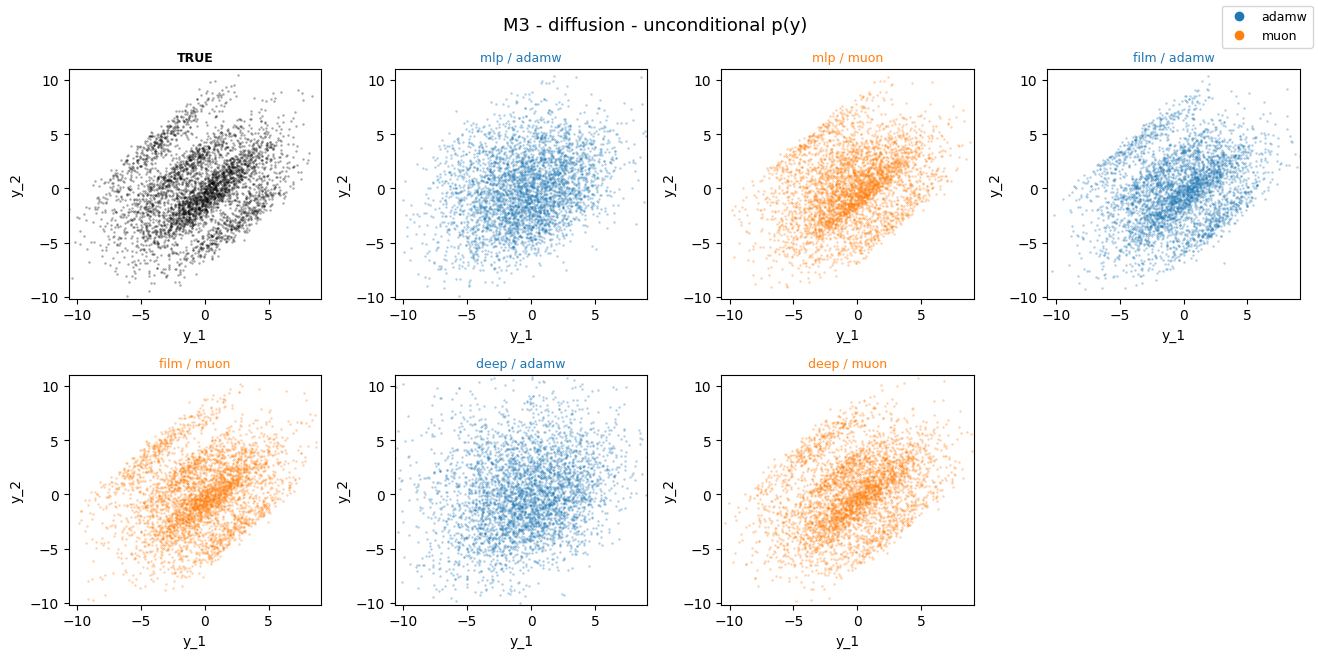

In [8]:
run_section("diffusion", "M3", "uncond")

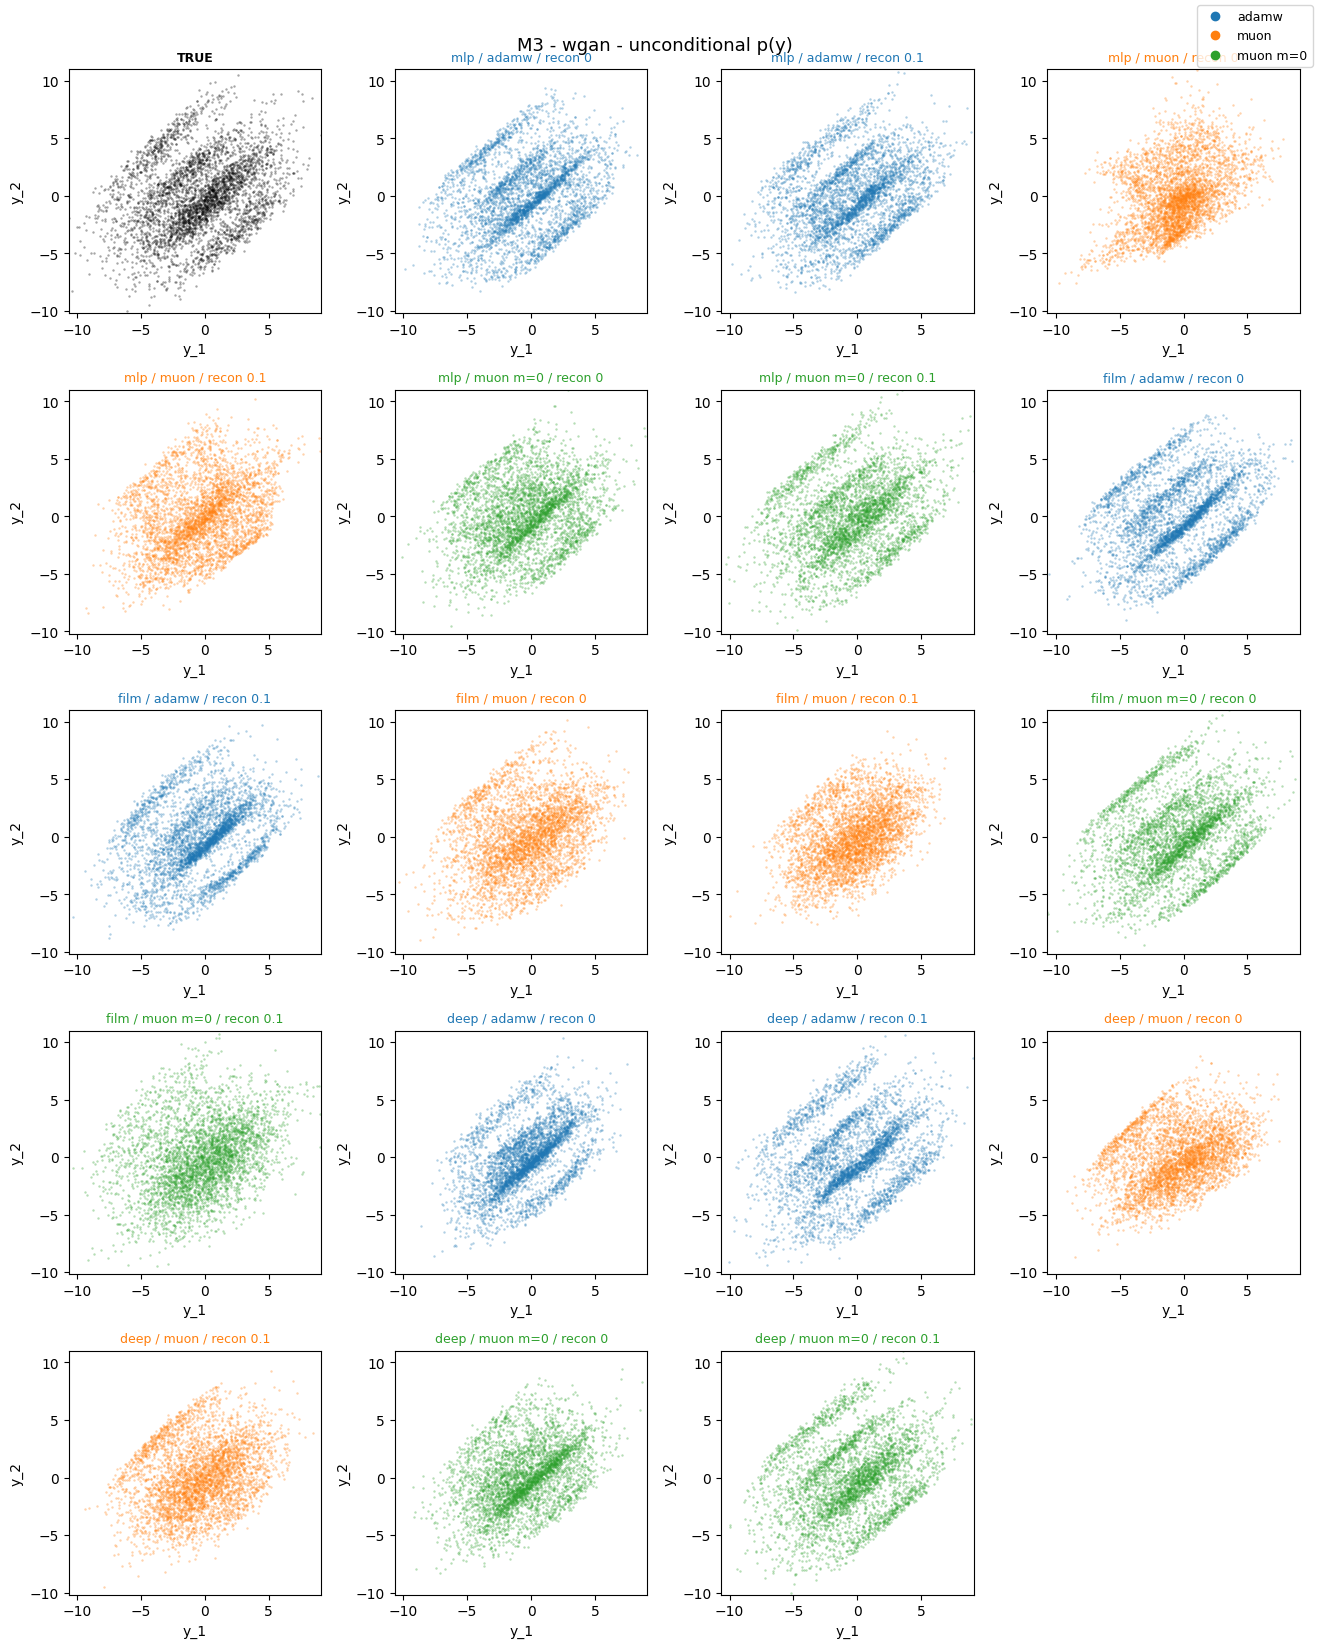

In [9]:
run_section("wgan", "M3", "uncond")

## M3 — conditional distribution of y

With `x` fixed, `p(y | x)` is the M3 spiral-noise blob shifted by `2x`.

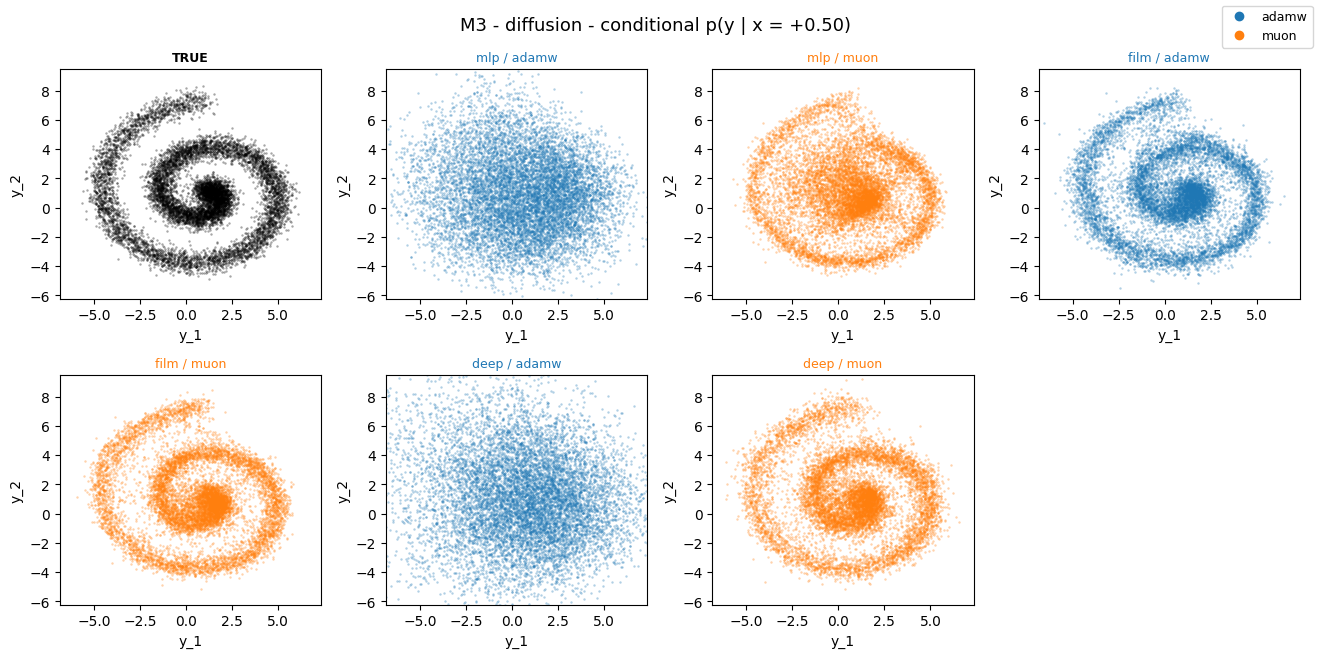

In [10]:
run_section("diffusion", "M3", "cond")

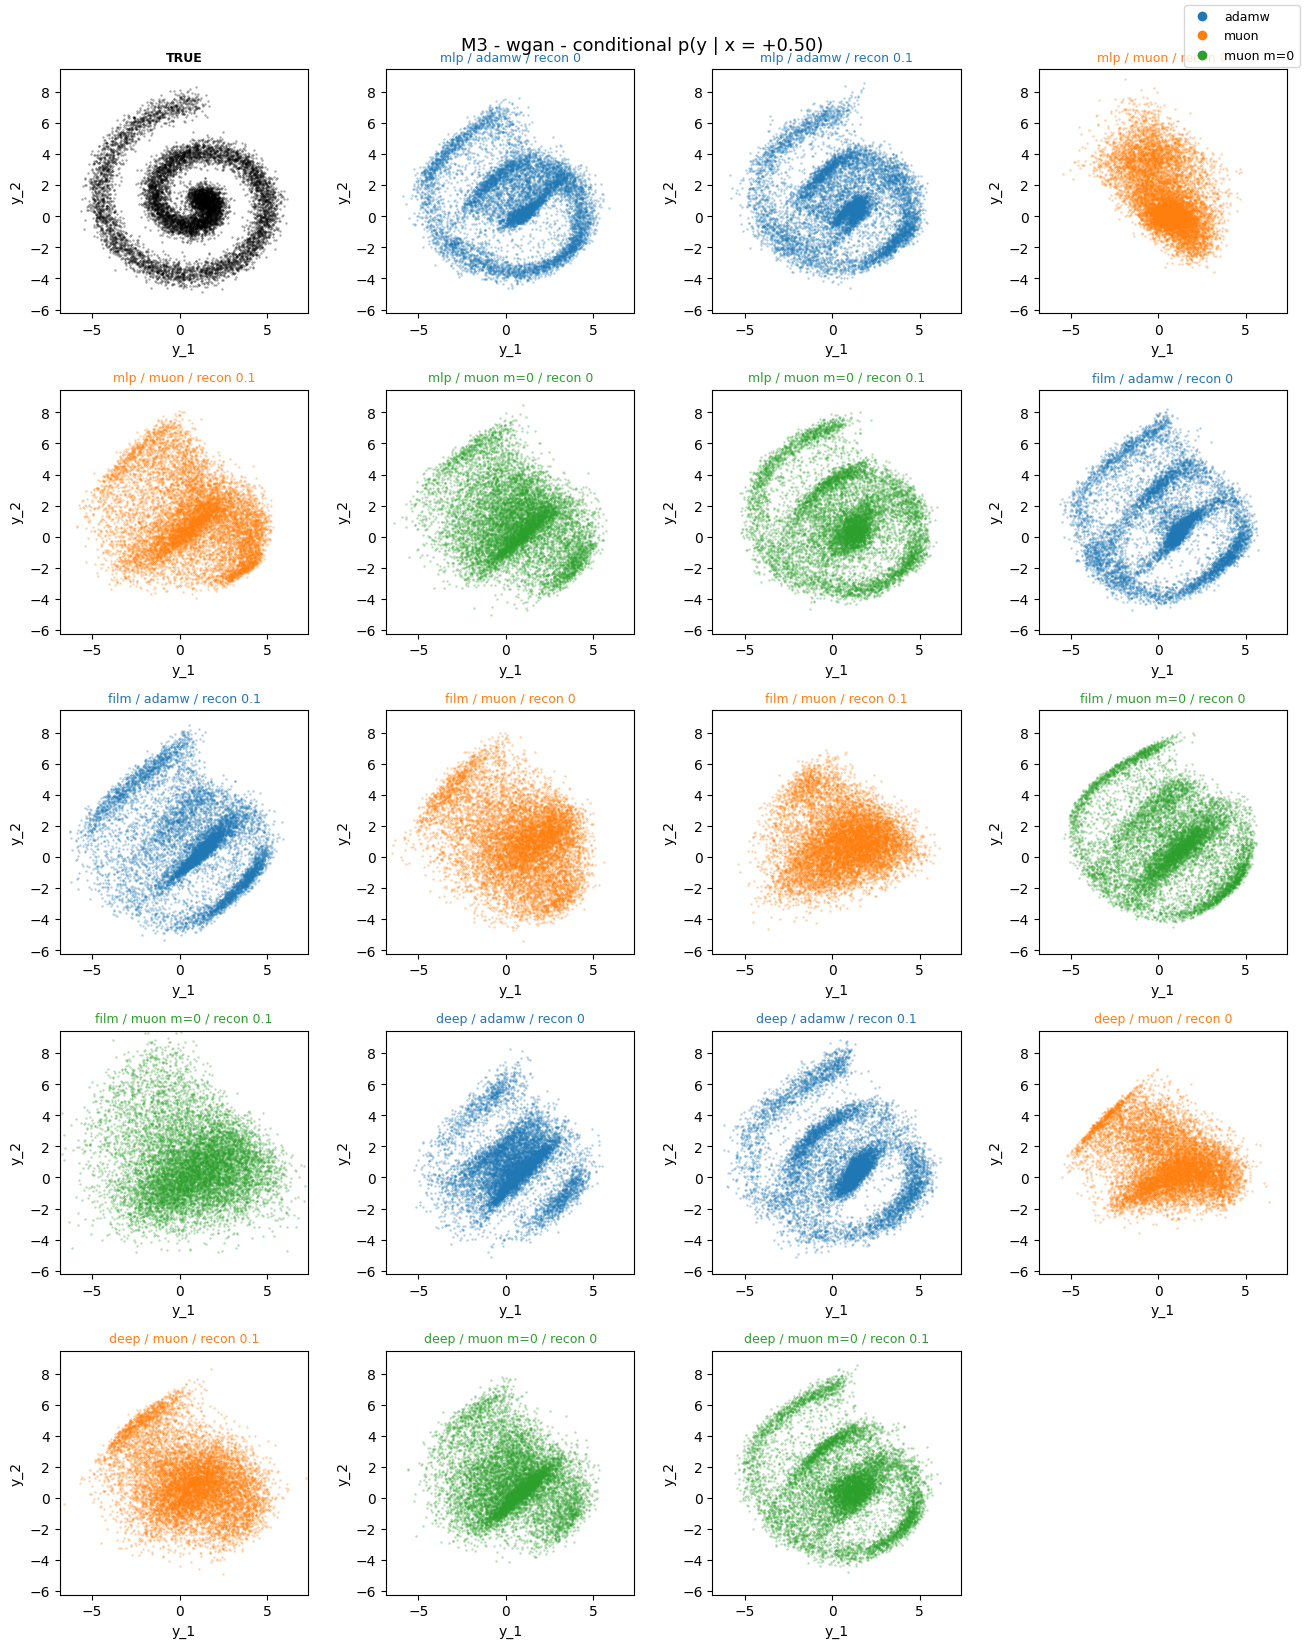

In [11]:
run_section("wgan", "M3", "cond")

## M4 — unconditional distribution of y

M4 noise is an independent 3-component Gaussian mixture per coordinate, so `p(y)` smears the 3x3 mixture grid along the `y_1 = y_2` diagonal as `x` varies.

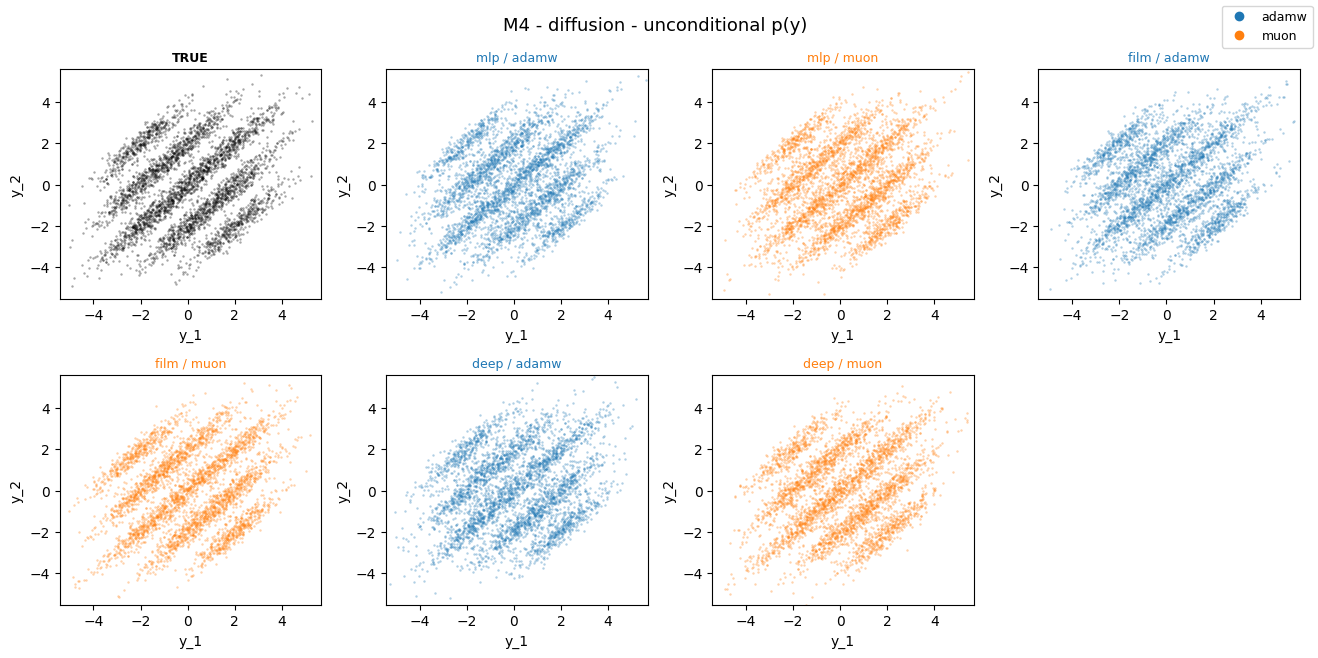

In [12]:
run_section("diffusion", "M4", "uncond")

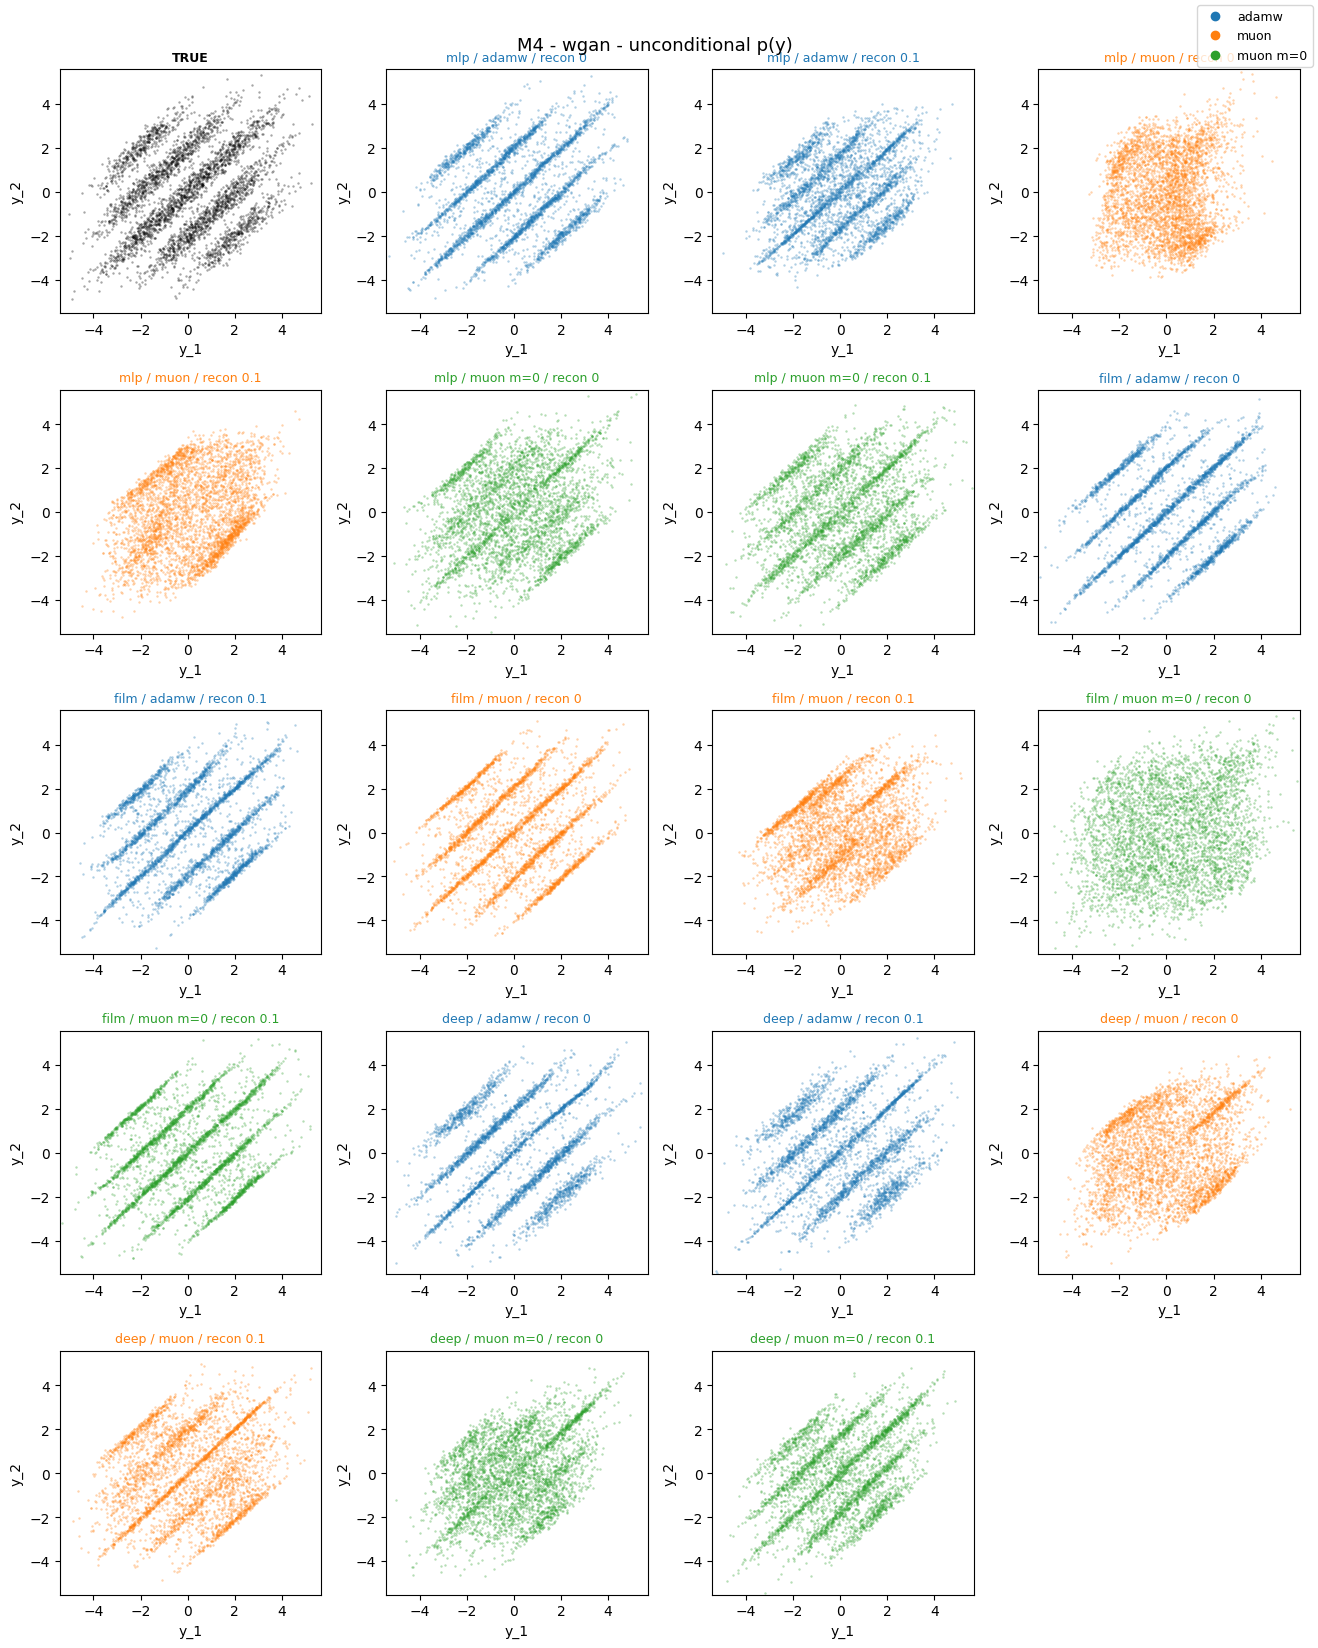

In [13]:
run_section("wgan", "M4", "uncond")

## M4 — conditional distribution of y

With `x` fixed, `p(y | x)` is the 3x3 grid of Gaussian-mixture blobs centered at `(x, x)`.

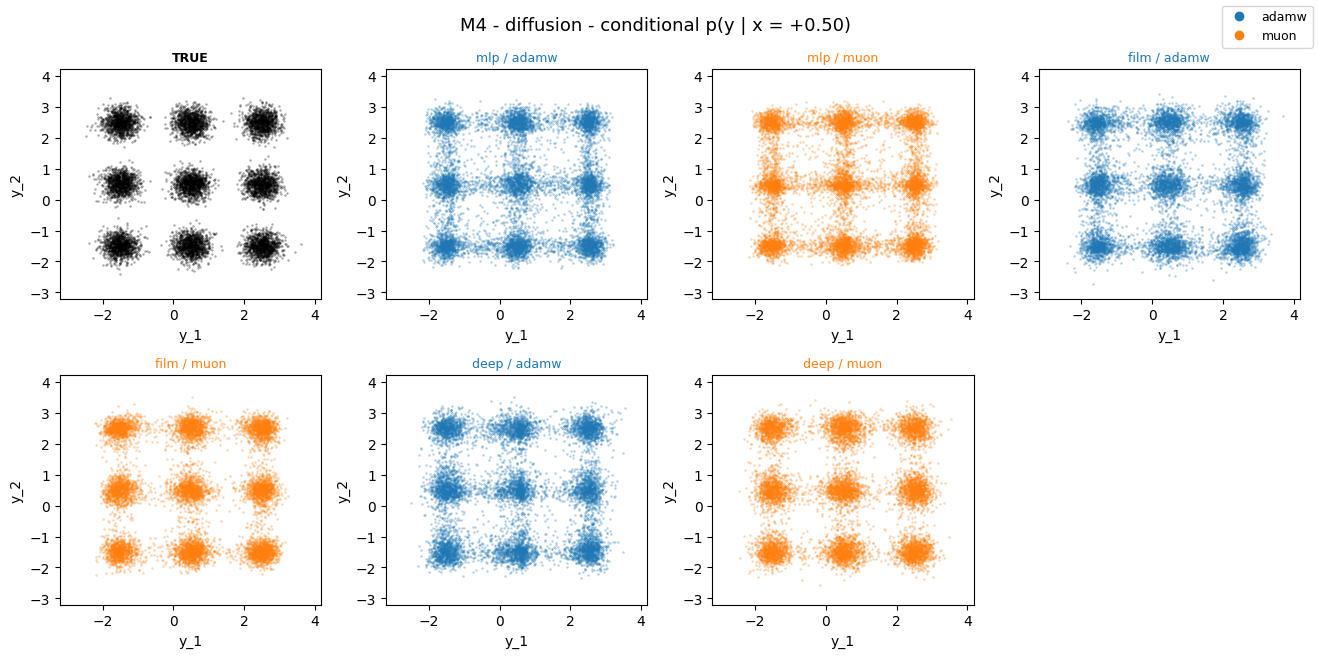

In [14]:
run_section("diffusion", "M4", "cond")

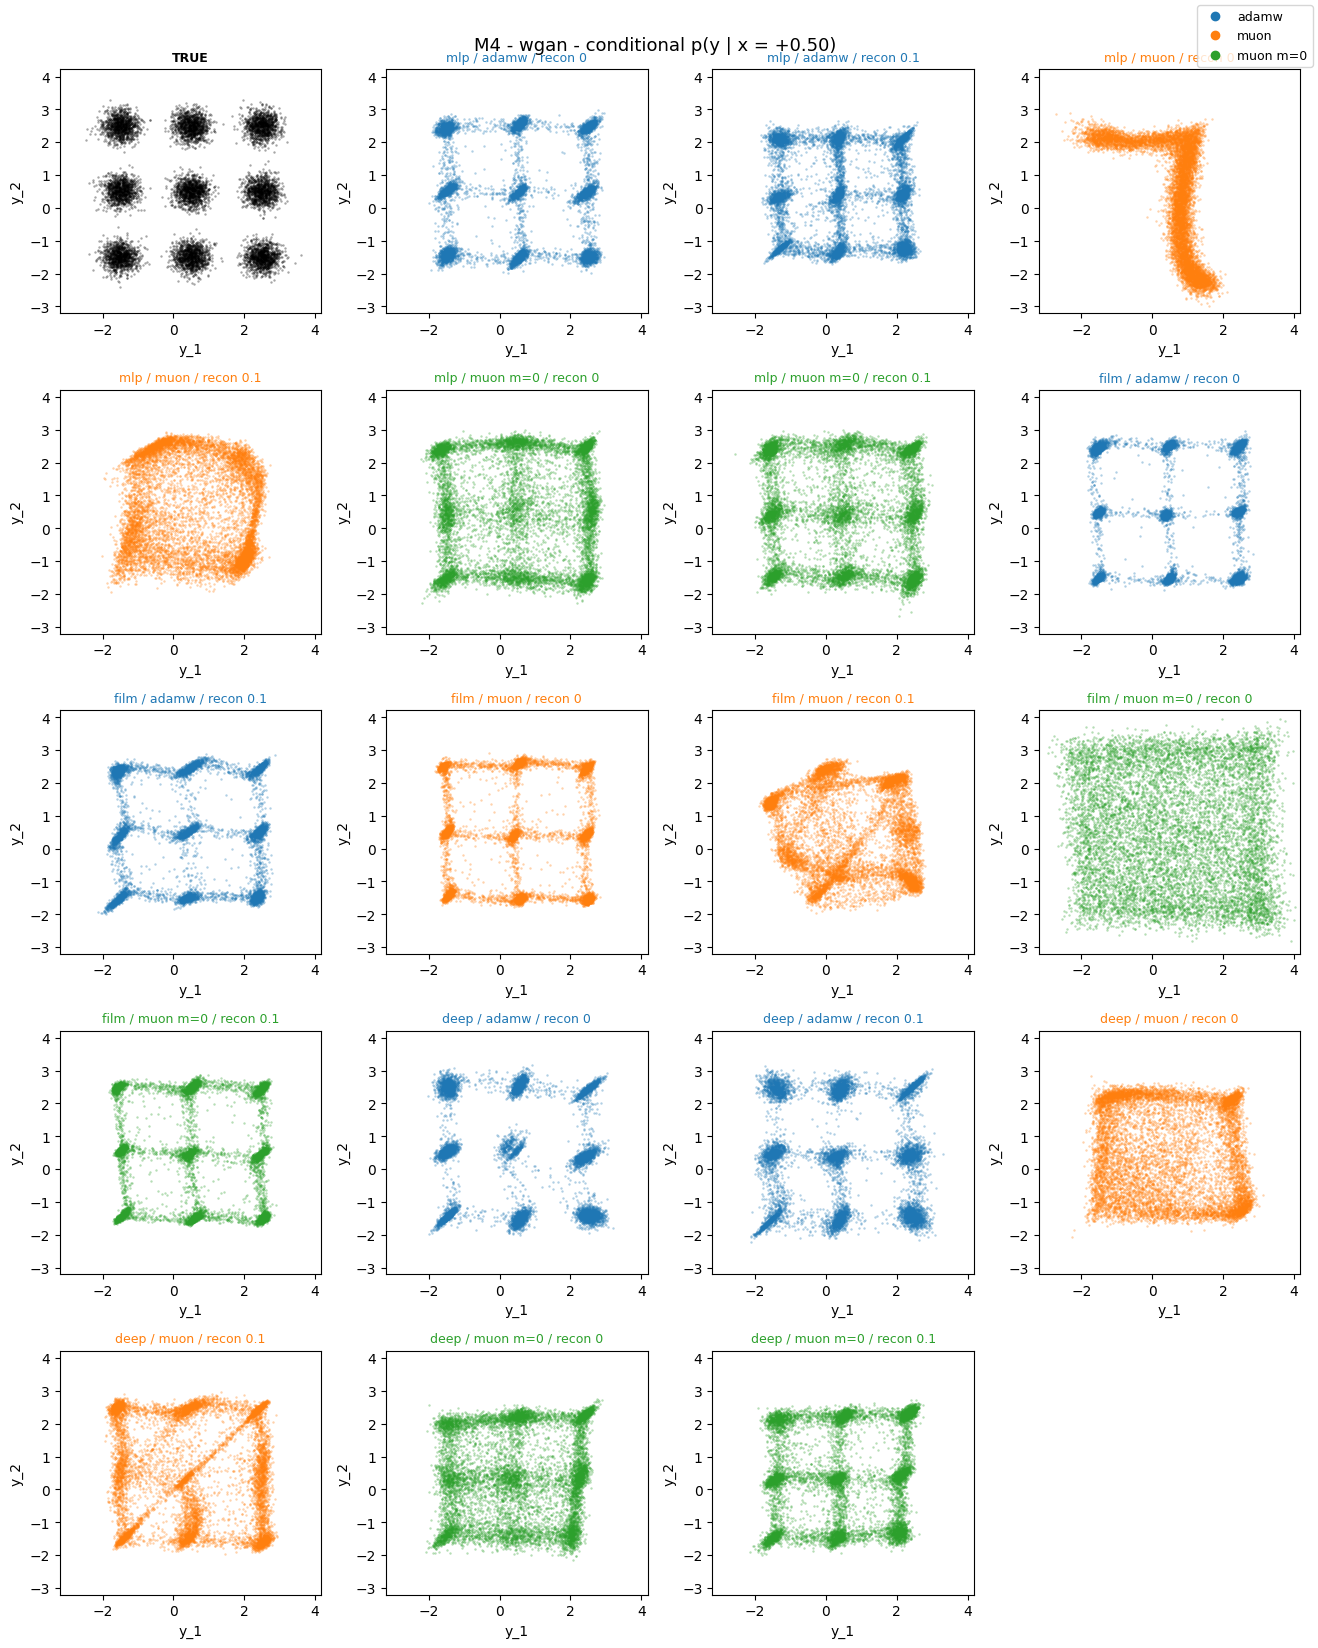

In [15]:
run_section("wgan", "M4", "cond")